## Imports and files

In [1]:
import os
import pickle
import re
import itertools
import matplotlib.pyplot as plt
import seaborn as sns
import time
# Date and time related imports
from datetime import datetime, timedelta

# Scientific libraries
import numpy as np
import pandas as pd
import scipy.io as sio
from scipy.interpolate import griddata
from scipy.stats import wilcoxon

from typing import List
from collections import Counter


## Function

In [2]:
def filter_events_by_rainfall(final_results_df, rain_filter_threshold, shift_threshold):
    """
    Filters out events with total rainfall below a specified threshold for both historical and future data.
    
    Parameters:
    - final_results_df: DataFrame containing event data.
    - rain_filter_threshold: Float, threshold for filtering out events based on total rainfall (mm).
    - shift_threshold: Integer, defines the range for y_shift_range calculation.

    Returns:
    - final_results_df: Filtered DataFrame.
    - EVENTS_L: List of unique event numbers in the filtered DataFrame.
    - y_shift_range: Numpy array of y_shift values based on the shift_threshold.
    - num_classes: Integer, number of classes (historical and future).
    """
    # Initialize a list to store event numbers to filter out
    event_nums_to_filter_out = []
    
    # Iterate over unique event numbers in the DataFrame
    for event in final_results_df['event_num'].unique():
        # Filter the DataFrame for the current event
        event_df = final_results_df[final_results_df['event_num'] == event]
        
        # Check if total rainfall for both historical and future is below the threshold
        if (event_df[('historical', 'full_basin', 'total_rain')] < rain_filter_threshold).all() and \
           (event_df[('future', 'full_basin', 'total_rain')] < rain_filter_threshold).all():
            event_nums_to_filter_out.append(event)
    
    # Filter out the events from the DataFrame
    final_results_df = final_results_df[~final_results_df['event_num'].isin(event_nums_to_filter_out)]
    print(f'{len(event_nums_to_filter_out)} events were removed due to total event rain smaller than {rain_filter_threshold} mm')
    
    # Generate a list of unique events after filtering
    EVENTS_L = list(final_results_df['event_num'].unique())
    
    # Calculate the y_shift_range
    y_shift_range = np.arange(-shift_threshold, shift_threshold + 1, 500)
    
    # Number of classes (historical and future)
    num_classes = 2
    
    return final_results_df, y_shift_range, num_classes


## MultiIndex([( 'event_num',                       '',                      ''),
            (         'x',                       '',                      ''),
            (         'y',                       '',                      ''),
            (         'd',                       '',                      ''),
            ('historical',        'basin discharge',       'total_discharge'),
            ('historical',        'basin discharge',         'max_discharge'),
            ('historical',        'basin discharge', 'swmm_max_outflow_time'),
            ('historical',        'basin discharge',    'runoff_coefficient'),
            ('historical',             'full_basin',   'max_10min_intensity'),
            ('historical',             'full_basin',   'max_20min_intensity'),
            ('historical',             'full_basin',   'max_30min_intensity'),
            ('historical',             'full_basin',   'max_60min_intensity'),
            ('historical',             'full_basin',  'max_120min_intensity'),
            ('historical',             'full_basin',  'max_240min_intensity'),
            ('historical',             'full_basin',  'max_360min_intensity'),
            ('historical',             'full_basin',  'max_720min_intensity'),
            ('historical',             'full_basin', 'max_1440min_intensity'),
            ('historical',             'full_basin',            'total_rain'),
            ('historical',            'before_peak',   'max_10min_intensity'),
            ('historical',            'before_peak',   'max_20min_intensity'),
            ('historical',            'before_peak',   'max_30min_intensity'),
            ('historical',            'before_peak',   'max_60min_intensity'),
            ('historical',            'before_peak',  'max_120min_intensity'),
            ('historical',            'before_peak',  'max_240min_intensity'),
            ('historical',            'before_peak',  'max_360min_intensity'),
            ('historical',            'before_peak',  'max_720min_intensity'),
            ('historical',            'before_peak', 'max_1440min_intensity'),
            ('historical',            'before_peak',            'total_rain'),
            ('historical',  'singular_subcatchment',   'max_10min_intensity'),
            ('historical',  'singular_subcatchment',   'max_20min_intensity'),
            ('historical',  'singular_subcatchment',   'max_30min_intensity'),
            ('historical',  'singular_subcatchment',   'max_60min_intensity'),
            ('historical',  'singular_subcatchment',  'max_120min_intensity'),
            ('historical',  'singular_subcatchment',  'max_240min_intensity'),
            ('historical',  'singular_subcatchment',  'max_360min_intensity'),
            ('historical',  'singular_subcatchment',  'max_720min_intensity'),
            ('historical',  'singular_subcatchment', 'max_1440min_intensity'),
            ('historical',  'singular_subcatchment',            'total_rain'),
            ('historical', 'Max_Specific_Discharge',         'max_discharge'),
            ('historical', 'Max_Specific_Discharge',       'total_discharge'),
            ('historical', 'Max_Specific_Discharge',    'runoff_coefficient'),
            ('historical', 'Min_Specific_Discharge',         'max_discharge'),
            ('historical', 'Min_Specific_Discharge',       'total_discharge'),
            ('historical', 'Min_Specific_Discharge',    'runoff_coefficient'),
            ('historical',         'Most_Urban_S27',         'max_discharge'),
            ('historical',         'Most_Urban_S27',       'total_discharge'),
            ('historical',         'Most_Urban_S27',    'runoff_coefficient'),
            ('historical',        'Least_Urban_S28',         'max_discharge'),
            ('historical',        'Least_Urban_S28',       'total_discharge'),
            ('historical',        'Least_Urban_S28',    'runoff_coefficient'),
            (    'future',        'basin discharge',       'total_discharge'),
            (    'future',        'basin discharge',         'max_discharge'),
            (    'future',        'basin discharge', 'swmm_max_outflow_time'),
            (    'future',        'basin discharge',    'runoff_coefficient'),
            (    'future',             'full_basin',   'max_10min_intensity'),
            (    'future',             'full_basin',   'max_20min_intensity'),
            (    'future',             'full_basin',   'max_30min_intensity'),
            (    'future',             'full_basin',   'max_60min_intensity'),
            (    'future',             'full_basin',  'max_120min_intensity'),
            (    'future',             'full_basin',  'max_240min_intensity'),
            (    'future',             'full_basin',  'max_360min_intensity'),
            (    'future',             'full_basin',  'max_720min_intensity'),
            (    'future',             'full_basin', 'max_1440min_intensity'),
            (    'future',             'full_basin',            'total_rain'),
            (    'future',            'before_peak',   'max_10min_intensity'),
            (    'future',            'before_peak',   'max_20min_intensity'),
            (    'future',            'before_peak',   'max_30min_intensity'),
            (    'future',            'before_peak',   'max_60min_intensity'),
            (    'future',            'before_peak',  'max_120min_intensity'),
            (    'future',            'before_peak',  'max_240min_intensity'),
            (    'future',            'before_peak',  'max_360min_intensity'),
            (    'future',            'before_peak',  'max_720min_intensity'),
            (    'future',            'before_peak', 'max_1440min_intensity'),
            (    'future',            'before_peak',            'total_rain'),
            (    'future',  'singular_subcatchment',   'max_10min_intensity'),
            (    'future',  'singular_subcatchment',   'max_20min_intensity'),
            (    'future',  'singular_subcatchment',   'max_30min_intensity'),
            (    'future',  'singular_subcatchment',   'max_60min_intensity'),
            (    'future',  'singular_subcatchment',  'max_120min_intensity'),
            (    'future',  'singular_subcatchment',  'max_240min_intensity'),
            (    'future',  'singular_subcatchment',  'max_360min_intensity'),
            (    'future',  'singular_subcatchment',  'max_720min_intensity'),
            (    'future',  'singular_subcatchment', 'max_1440min_intensity'),
            (    'future',  'singular_subcatchment',            'total_rain'),
            (    'future', 'Max_Specific_Discharge',         'max_discharge'),
            (    'future', 'Max_Specific_Discharge',       'total_discharge'),
            (    'future', 'Max_Specific_Discharge',    'runoff_coefficient'),
            (    'future', 'Min_Specific_Discharge',         'max_discharge'),
            (    'future', 'Min_Specific_Discharge',       'total_discharge'),
            (    'future', 'Min_Specific_Discharge',    'runoff_coefficient'),
            (    'future',         'Most_Urban_S27',         'max_discharge'),
            (    'future',         'Most_Urban_S27',       'total_discharge'),
            (    'future',         'Most_Urban_S27',    'runoff_coefficient'),
            (    'future',        'Least_Urban_S28',         'max_discharge'),
            (    'future',        'Least_Urban_S28',       'total_discharge'),
            (    'future',        'Least_Urban_S28',    'runoff_coefficient')],
           )

# Define Parameters

In [3]:
# n = 200           # number of samples (for each event)
shift_thershold = 20000  # meters
rain_filter_threshold = 10 ## mm unitis


sim_dir = r"D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change\pickles\Urbanization_comparsion"

rain_shift_classes = [
    ('urbanization_1_0.pkl', 'urbanization_1_0', '39% urbanization'),
    ('urbanization_1_1.pkl', 'urbanization_1_1', '42% urbanization'),
    ('urbanization_1_2.pkl', 'urbanization_1_2', '46% urbanization'),
    ('urbanization_1_3.pkl', 'urbanization_1_3', '49% urbanization'),
    ('urbanization_1_4.pkl', 'urbanization_1_4', '53% urbanization'),
    ('urbanization_1_5.pkl', 'urbanization_1_5', '57% urbanization'),
    ('urbanization_2_0.pkl', 'urbanization_2_0', '73% urbanization'),
    ('urbanization_3_0.pkl', 'urbanization_3_0', '81% urbanization'),
    ('urbanization_5_0.pkl', 'urbanization_5_0', '87% urbanization')]


#### SELECT the relevent distrbution 
##### 1.distance (1/r) -> y_distance_samples->  put 0
##### 2.Uniform -> y_uniform_samples-> put 1
##### 3.Triangular -> y_triangular_samples -> put 2


In [4]:
# sim_dir = r"D:\Development\RESEARCH\Raanana\SWMM\from_radar\Climate_Change\pickles"
# # Each scenario with comparsion to historical rain without urbaniztion
# rain_shift_classes = [
#     ('rain_shift_results_0_8_urbanization.pkl', 'future_0_8_urbanization', 'Climate Chagne 0.8 urbanization'),
#     ('rain_shift_results_0_9_urbanization.pkl', 'future_0_9_urbanization', 'Climate Chagne 0.9 urbanization'),
#     ('rain_shift_results.pkl', 'optimal_model', 'Climate Chagne No urbanization'),
#     ('rain_shift_results_1_1_urbanization.pkl', 'future_1_1_urbanization', 'Climate Chagne 1.1 urbanization'),
#     ('rain_shift_results_1_2_urbanization.pkl', 'future_1_2_urbanization', 'Climate Chagne 1.2 urbanization'),
#     ('rain_shift_results_1_3_urbanization.pkl', 'future_1_3_urbanization', 'Climate Chagne 1.3 urbanization'),
#     ('rain_shift_results_1_4_urbanization.pkl', 'future_1_4_urbanization', 'Climate Chagne 1.4 urbanization'),
#     ('rain_shift_results_1_5_urbanization.pkl', 'future_1_5_urbanization', 'Climate Chagne 1.5 urbanization'),
#     ('rain_shift_results_subcatchment_urbanization.pkl', 'future_subcatchment_urbanization', 'Climate Chagne Manual urbanization'),
#     ('rain_shift_results_0_8_urbanization_historical_rain.pkl', 'future_0_8_urbanization_historical_rain', '0.8 urbanization'),
#     ('rain_shift_results_0_9_urbanization_historical_rain.pkl', 'future_0_9_urbanization_historical_rain', '0.9 urbanization'),
# #     ('rain_shift_results_control.pkl', 'future_control_no_urbanization_historical_rain', 'Control'),
#     ('rain_shift_results_1_1_urbanization_historical_rain.pkl', 'future_1_1_urbanization_historical_rain', '1.1 urbanization'),
#     ('rain_shift_results_1_2_urbanization_historical_rain.pkl', 'future_1_2_urbanization_historical_rain', '1.2 urbanization'),
#     ('rain_shift_results_1_3_urbanization_historical_rain.pkl', 'future_1_3_urbanization_historical_rain', '1.3 urbanization'),
#     ('rain_shift_results_1_4_urbanization_historical_rain.pkl', 'future_1_4_urbanization_historical_rain', '1.4 urbanization'),
#     ('rain_shift_results_1_5_urbanization_historical_rain.pkl', 'future_1_5_urbanization_historical_rain', '1.5 urbanization'),
# ]

In [5]:
# Define the columns dynamically
historical_column = ('historical', 'basin discharge', 'max_discharge')
future_column = ('future', 'basin discharge', 'max_discharge')

# historical_column = ('historical', 'full_basin', 'max_30min_intensity')
# future_column = ('future', 'full_basin', 'max_30min_intensity')

# Load the data

In [6]:
# Define the columns dynamically
historical_column = ('historical', 'basin discharge', 'max_discharge')
future_column = ('future', 'basin discharge', 'max_discharge')

# historical_column = ('historical', 'full_basin', 'max_30min_intensity')
# future_column = ('future', 'full_basin', 'max_30min_intensity')

# Define the dynamic title based on the last two elements of the column tuple
dynamic_title = f"{historical_column[1]} - {historical_column[2]}"
x_title = f"{historical_column[2]}" 
# Lists to store values for both scenarios
urbanization_39_historical = []
urbanization_39_future = []

urbanization_87_historical = []
urbanization_87_future = []

# Loop through the scenarios
for pickle_file, file_name, label_name in rain_shift_classes:
    print(label_name)
    # Construct file paths
    pickle_file_path = os.path.join(sim_dir, pickle_file)
    save_dir = os.path.join(
        r'D:\Development\RESEARCH\Raanana\figures\climate_change_shifts', 
        file_name, 
        'storm_sample_wilcoxcon_urbanization_comparsion'
    )

    # Create directory if it doesn't exist
    os.makedirs(save_dir, exist_ok=True)

    # Load data
    final_results_df = pd.read_pickle(pickle_file_path)
    
    filtered_df, y_shift_range, num_classes = filter_events_by_rainfall(
        final_results_df, 
        rain_filter_threshold, 
        shift_thershold
    )

    # Check for urbanization scenarios
    if label_name == '87% urbanization' or label_name == '39% urbanization':
        # Construct the Excel file path
        excel_file_path = os.path.join(save_dir, f"{label_name}_filtered_data.csv")

        # Save the DataFrame to the constructed file path
        filtered_df.to_csv(excel_file_path, index=False)
        
        print(f"Saved filtered data for {label_name} to {excel_file_path}")

        # Extract values for all points
        historical_values = filtered_df[historical_column].values
        future_values = filtered_df[future_column].values
        
        # Save points to respective lists
        if label_name == '39% urbanization':
            urbanization_39_historical.extend(historical_values)
            urbanization_39_future.extend(future_values)
        elif label_name == '87% urbanization':
            urbanization_87_historical.extend(historical_values)
            urbanization_87_future.extend(future_values)

# Calculate medians for each dataset
median_39_historical = np.median(urbanization_39_historical)
median_39_future = np.median(urbanization_39_future)

median_87_historical = np.median(urbanization_87_historical)
median_87_future = np.median(urbanization_87_future)

39% urbanization
8 events were removed due to total event rain smaller than 10 mm
Saved filtered data for 39% urbanization to D:\Development\RESEARCH\Raanana\figures\climate_change_shifts\urbanization_1_0\storm_sample_wilcoxcon_urbanization_comparsion\39% urbanization_filtered_data.csv
42% urbanization
8 events were removed due to total event rain smaller than 10 mm
46% urbanization
8 events were removed due to total event rain smaller than 10 mm
49% urbanization
8 events were removed due to total event rain smaller than 10 mm
53% urbanization
8 events were removed due to total event rain smaller than 10 mm
57% urbanization
8 events were removed due to total event rain smaller than 10 mm
73% urbanization
8 events were removed due to total event rain smaller than 10 mm
81% urbanization
8 events were removed due to total event rain smaller than 10 mm
87% urbanization
8 events were removed due to total event rain smaller than 10 mm
Saved filtered data for 87% urbanization to D:\Developmen

# Plot

## Scatter

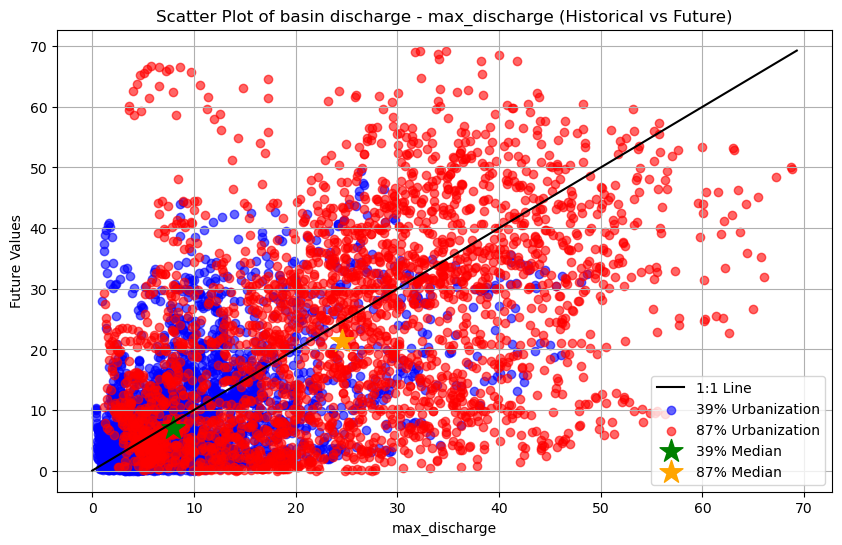

Median for 39% urbanization (Historical): 7.902443170547485
Median for 39% urbanization (Future): 6.976215839385986
Median for 87% urbanization (Historical): 24.538789749145508
Median for 87% urbanization (Future): 21.325593948364258


In [7]:
# Create scatter plot
plt.figure(figsize=(10, 6))

# Plot points for 39% urbanization
plt.scatter(
    urbanization_39_historical,
    urbanization_39_future,
    c='blue', alpha=0.6, label='39% Urbanization'
)

# Plot points for 87% urbanization
plt.scatter(
    urbanization_87_historical,
    urbanization_87_future,
    c='red', alpha=0.6, label='87% Urbanization'
)

# Plot 1:1 line
max_value = max(
    max(urbanization_39_historical + urbanization_39_future),
    max(urbanization_87_historical + urbanization_87_future)
)
min_value = min(
    min(urbanization_39_historical + urbanization_39_future),
    min(urbanization_87_historical + urbanization_87_future)
)
plt.plot(
    [min_value, max_value], 
    [min_value, max_value], 
    color='black', linestyle='-', label='1:1 Line'
)

# Add medians as points with larger markers and labels
plt.scatter(
    [median_39_historical], 
    [median_39_future], 
    color='green', 
    marker='*', 
    s=300,  # Increase marker size
    label='39% Median'
)

plt.scatter(
    [median_87_historical], 
    [median_87_future], 
    color='orange', 
    marker='*', 
    s=300,  # Increase marker size
    label='87% Median'
)

# Add titles, labels, and legend
plt.title(f"Scatter Plot of {dynamic_title} (Historical vs Future)")
plt.xlabel(f'{x_title}')
plt.ylabel('Future Values')
plt.legend()
plt.grid(True)

# Show the plot
plt.show()

# Print median values
print(f"Median for 39% urbanization (Historical): {median_39_historical}")
print(f"Median for 39% urbanization (Future): {median_39_future}")
print(f"Median for 87% urbanization (Historical): {median_87_historical}")
print(f"Median for 87% urbanization (Future): {median_87_future}")

## CDF

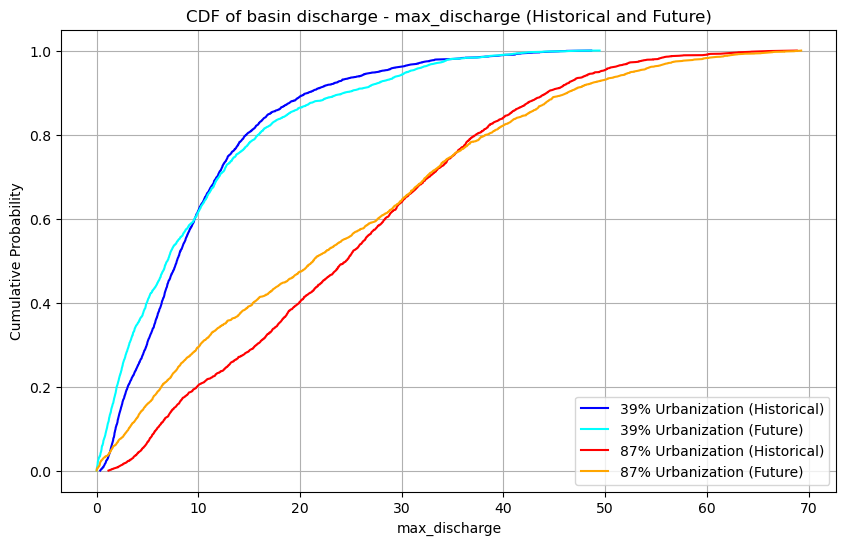

In [8]:
# Plot CDF
plt.figure(figsize=(10, 6))

# Plot CDF for 39% urbanization (historical and future)
plt.plot(
    np.sort(urbanization_39_historical),
    np.linspace(0, 1, len(urbanization_39_historical), endpoint=True),
    label='39% Urbanization (Historical)', color='blue'
)
plt.plot(
    np.sort(urbanization_39_future),
    np.linspace(0, 1, len(urbanization_39_future), endpoint=True),
    label='39% Urbanization (Future)', color='cyan'
)

# Plot CDF for 87% urbanization (historical and future)
plt.plot(
    np.sort(urbanization_87_historical),
    np.linspace(0, 1, len(urbanization_87_historical), endpoint=True),
    label='87% Urbanization (Historical)', color='red'
)
plt.plot(
    np.sort(urbanization_87_future),
    np.linspace(0, 1, len(urbanization_87_future), endpoint=True),
    label='87% Urbanization (Future)', color='orange'
)

# Add labels and legend

plt.title(f'CDF of {dynamic_title} (Historical and Future)')
plt.xlabel(f'{x_title}')
plt.ylabel('Cumulative Probability')
# plt.xlim(40,55)
# plt.ylim(0.95,1)
plt.legend()
plt.grid(True)

# Show plot
plt.show()


C:\Users\raznu\AppData\Local\Temp\ipykernel_6960\1741428241.py:75: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


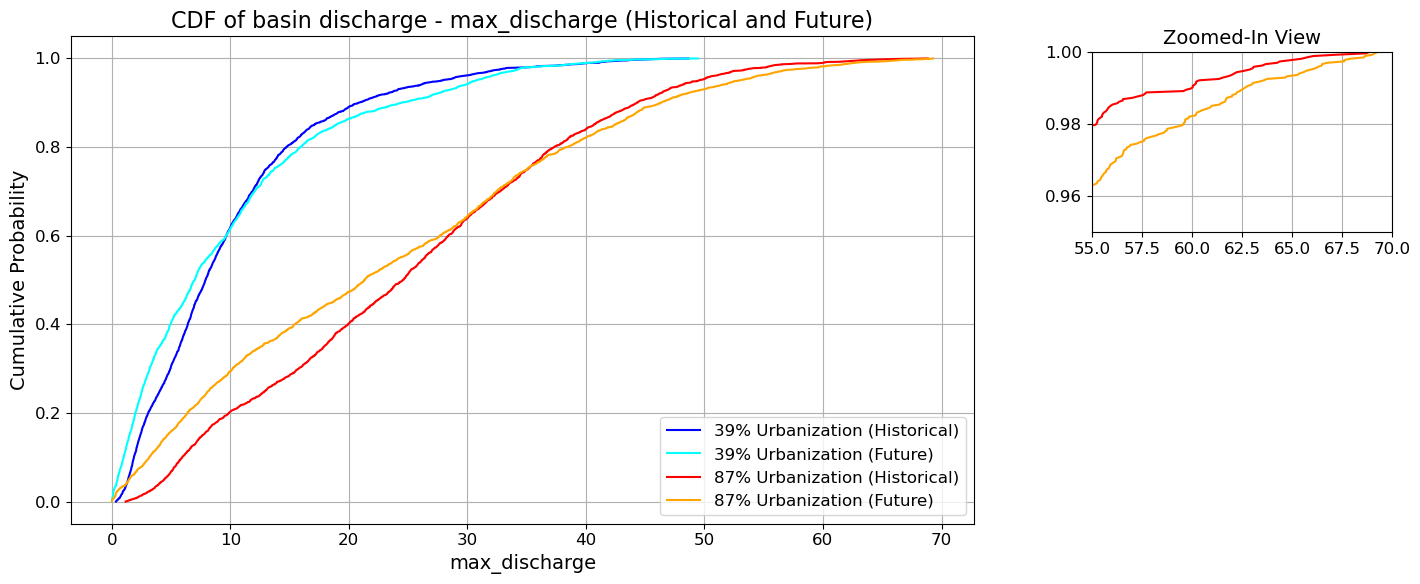

In [9]:
from matplotlib import pyplot as plt

# Set font sizes
plt.rc('font', size=12)          # Default text size
plt.rc('axes', titlesize=16)     # Title font size
plt.rc('axes', labelsize=14)     # Axes labels font size
plt.rc('legend', fontsize=12)    # Legend font size
plt.rc('xtick', labelsize=12)    # X-axis tick font size
plt.rc('ytick', labelsize=12)    # Y-axis tick font size

# Create the main plot
plt.figure(figsize=(10, 6))

# Plot CDF for 39% urbanization (historical and future)
plt.plot(
    np.sort(urbanization_39_historical),
    np.linspace(0, 1, len(urbanization_39_historical), endpoint=True),
    label='39% Urbanization (Historical)', color='blue'
)
plt.plot(
    np.sort(urbanization_39_future),
    np.linspace(0, 1, len(urbanization_39_future), endpoint=True),
    label='39% Urbanization (Future)', color='cyan'
)

# Plot CDF for 87% urbanization (historical and future)
plt.plot(
    np.sort(urbanization_87_historical),
    np.linspace(0, 1, len(urbanization_87_historical), endpoint=True),
    label='87% Urbanization (Historical)', color='red'
)
plt.plot(
    np.sort(urbanization_87_future),
    np.linspace(0, 1, len(urbanization_87_future), endpoint=True),
    label='87% Urbanization (Future)', color='orange'
)

# Add labels and legend
plt.title(f'CDF of {dynamic_title} (Historical and Future)')
plt.xlabel(f'{x_title}')
plt.ylabel('Cumulative Probability')
plt.legend()
plt.grid(True)

# Add a separate inset figure for the zoomed-in view
zoom_inset = plt.axes([1.1, 0.6, 0.3, 0.3])  # Position inset outside the main plot
zoom_inset.plot(
    np.sort(urbanization_39_historical),
    np.linspace(0, 1, len(urbanization_39_historical), endpoint=True),
    color='blue'
)
zoom_inset.plot(
    np.sort(urbanization_39_future),
    np.linspace(0, 1, len(urbanization_39_future), endpoint=True),
    color='cyan'
)
zoom_inset.plot(
    np.sort(urbanization_87_historical),
    np.linspace(0, 1, len(urbanization_87_historical), endpoint=True),
    color='red'
)
zoom_inset.plot(
    np.sort(urbanization_87_future),
    np.linspace(0, 1, len(urbanization_87_future), endpoint=True),
    color='orange'
)

# Set zoom limits
zoom_inset.set_xlim(55, 70)  # Adjust based on your data
zoom_inset.set_ylim(0.95, 1)  # Adjust based on your data
zoom_inset.grid(True)
zoom_inset.set_title("Zoomed-In View", fontsize=14)  # Inset title font size

# Show the full figure
plt.tight_layout()
plt.show()


# Hist

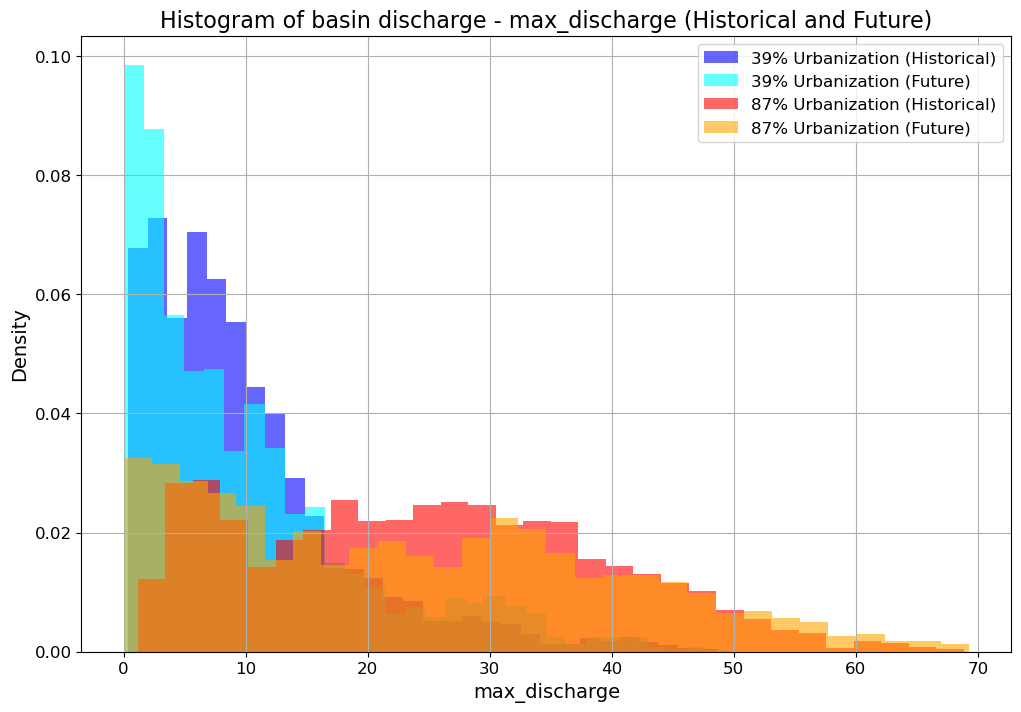

In [10]:
# Plot histogram
plt.figure(figsize=(12, 8))

# Histogram for 39% urbanization (historical and future)
plt.hist(
    urbanization_39_historical, bins=30, alpha=0.6, label='39% Urbanization (Historical)', color='blue', density=True
)
plt.hist(
    urbanization_39_future, bins=30, alpha=0.6, label='39% Urbanization (Future)', color='cyan', density=True
)

# Histogram for 87% urbanization (historical and future)
plt.hist(
    urbanization_87_historical, bins=30, alpha=0.6, label='87% Urbanization (Historical)', color='red', density=True
)
plt.hist(
    urbanization_87_future, bins=30, alpha=0.6, label='87% Urbanization (Future)', color='orange', density=True
)

# Add labels and legend


plt.title(f'Histogram of {dynamic_title} (Historical and Future)')
plt.xlabel(f'{x_title}')
plt.ylabel('Density')
plt.legend()
plt.grid(True)

# Show plot
plt.show()


# Hist differences

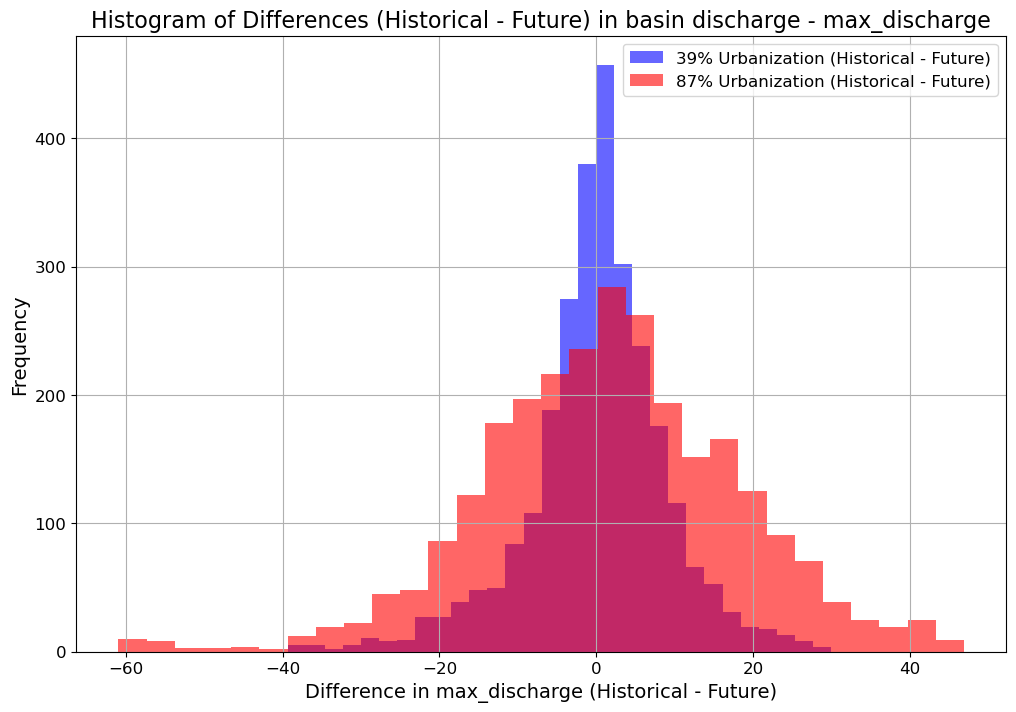

In [11]:
# Calculate differences between historical and future values
difference_39 = np.array(urbanization_39_historical) - np.array(urbanization_39_future)
difference_87 = np.array(urbanization_87_historical) - np.array(urbanization_87_future)

# Plot histogram
plt.figure(figsize=(12, 8))

# Histogram for differences in 39% urbanization
plt.hist(
    difference_39, bins=30, alpha=0.6, label='39% Urbanization (Historical - Future)', color='blue'
)

# Histogram for differences in 87% urbanization
plt.hist(
    difference_87, bins=30, alpha=0.6, label='87% Urbanization (Historical - Future)', color='red'
)

# Add labels and legend
plt.title(f'Histogram of Differences (Historical - Future) in {dynamic_title}')
plt.xlabel(f'Difference in {x_title} (Historical - Future)')
plt.ylabel('Frequency')
plt.legend()
plt.grid(True)

# Show plot
plt.show()


# PDF

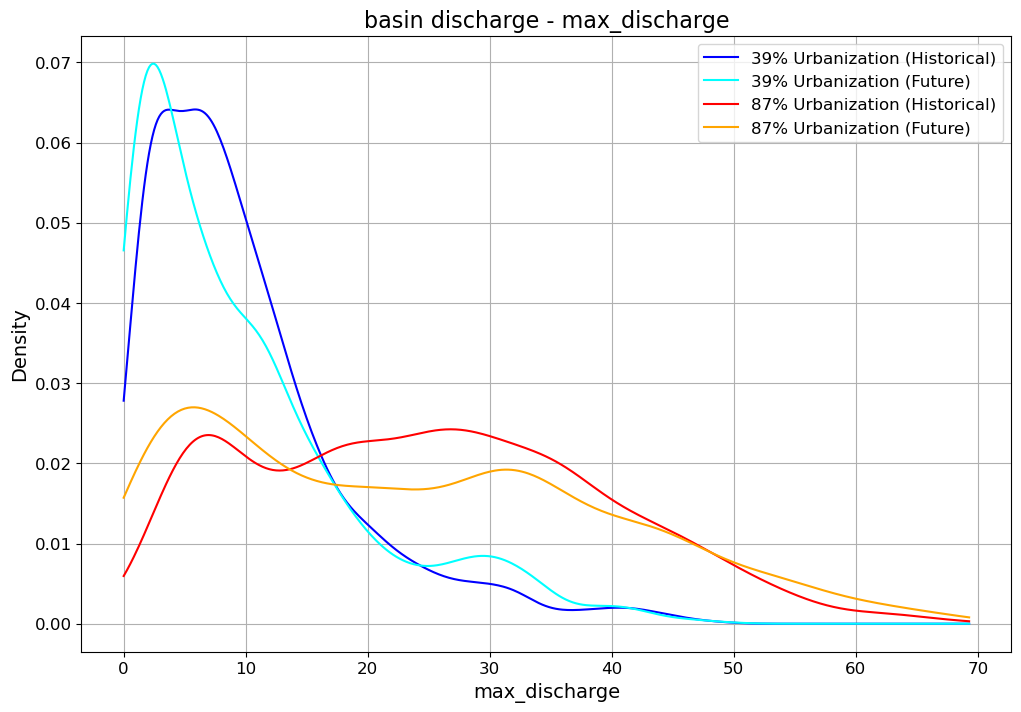

In [12]:
from scipy.stats import gaussian_kde

plt.figure(figsize=(12, 8))

# KDE for each dataset
kde_39_hist = gaussian_kde(urbanization_39_historical)
kde_39_fut = gaussian_kde(urbanization_39_future)
kde_87_hist = gaussian_kde(urbanization_87_historical)
kde_87_fut = gaussian_kde(urbanization_87_future)

x_range = np.linspace(min(urbanization_39_historical + urbanization_39_future + 
                          urbanization_87_historical + urbanization_87_future),
                      max(urbanization_39_historical + urbanization_39_future + 
                          urbanization_87_historical + urbanization_87_future), 500)

plt.plot(x_range, kde_39_hist(x_range), label='39% Urbanization (Historical)', color='blue')
plt.plot(x_range, kde_39_fut(x_range), label='39% Urbanization (Future)', color='cyan')
plt.plot(x_range, kde_87_hist(x_range), label='87% Urbanization (Historical)', color='red')
plt.plot(x_range, kde_87_fut(x_range), label='87% Urbanization (Future)', color='orange')

# Add labels and legend

plt.title(f'{dynamic_title}')
plt.xlabel(f'{x_title}')
plt.ylabel('Density')
plt.legend()
plt.grid(True)

# Show plot
plt.show()


# scatter - sort

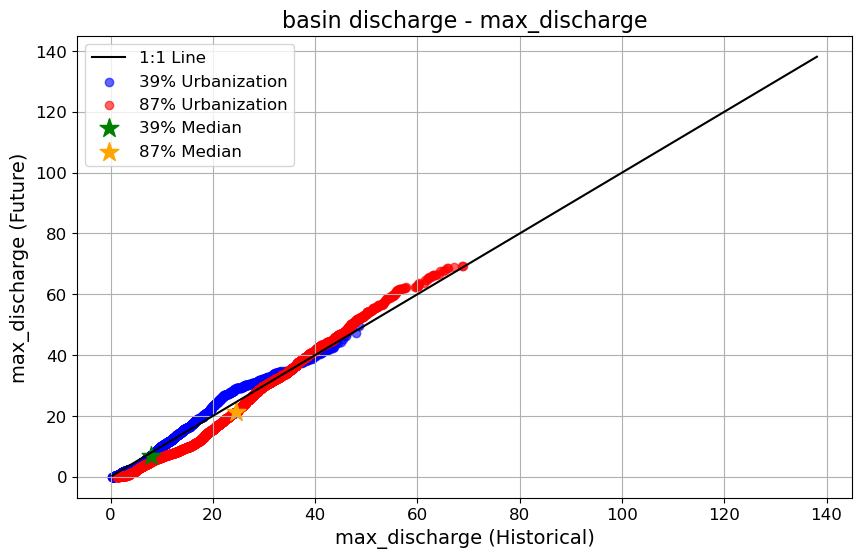

Median for 39% urbanization (Historical): 7.902443170547485
Median for 39% urbanization (Future): 6.976215839385986
Median for 87% urbanization (Historical): 24.538789749145508
Median for 87% urbanization (Future): 21.325593948364258


In [13]:
# Sort the values for each dataset
sorted_39_historical = np.sort(urbanization_39_historical)
sorted_39_future = np.sort(urbanization_39_future)

sorted_87_historical = np.sort(urbanization_87_historical)
sorted_87_future = np.sort(urbanization_87_future)

# Calculate medians for each sorted dataset
median_39_historical = np.median(sorted_39_historical)
median_39_future = np.median(sorted_39_future)

median_87_historical = np.median(sorted_87_historical)
median_87_future = np.median(sorted_87_future)

# Create scatter plot
plt.figure(figsize=(10, 6))

# Plot points for 39% urbanization
plt.scatter(
    sorted_39_historical,
    sorted_39_future,
    c='blue', alpha=0.6, label='39% Urbanization'
)

# Plot points for 87% urbanization
plt.scatter(
    sorted_87_historical,
    sorted_87_future,
    c='red', alpha=0.6, label='87% Urbanization'
)

# Plot 1:1 line
max_value = max(
    max(sorted_39_historical + sorted_39_future),
    max(sorted_87_historical + sorted_87_future)
)
min_value = min(
    min(sorted_39_historical + sorted_39_future),
    min(sorted_87_historical + sorted_87_future)
)
plt.plot(
    [min_value, max_value], 
    [min_value, max_value], 
    color='black', linestyle='-', label='1:1 Line'
)

# Add medians as points with larger markers and labels
plt.scatter(
    [median_39_historical], 
    [median_39_future], 
    color='green', 
    marker='*', 
    s=200,  # Increase marker size
    label='39% Median'
)

plt.scatter(
    [median_87_historical], 
    [median_87_future], 
    color='orange', 
    marker='*', 
    s=200,  # Increase marker size
    label='87% Median'
)

# Add titles, labels, and legend
plt.title(f'{dynamic_title}')
plt.xlabel(f"{x_title} (Historical)")
plt.ylabel(f"{x_title} (Future)")
plt.legend()
plt.grid(True)

# Show the plot
plt.show()

# Print median values
print(f"Median for 39% urbanization (Historical): {median_39_historical}")
print(f"Median for 39% urbanization (Future): {median_39_future}")
print(f"Median for 87% urbanization (Historical): {median_87_historical}")
print(f"Median for 87% urbanization (Future): {median_87_future}")


# Box Plot

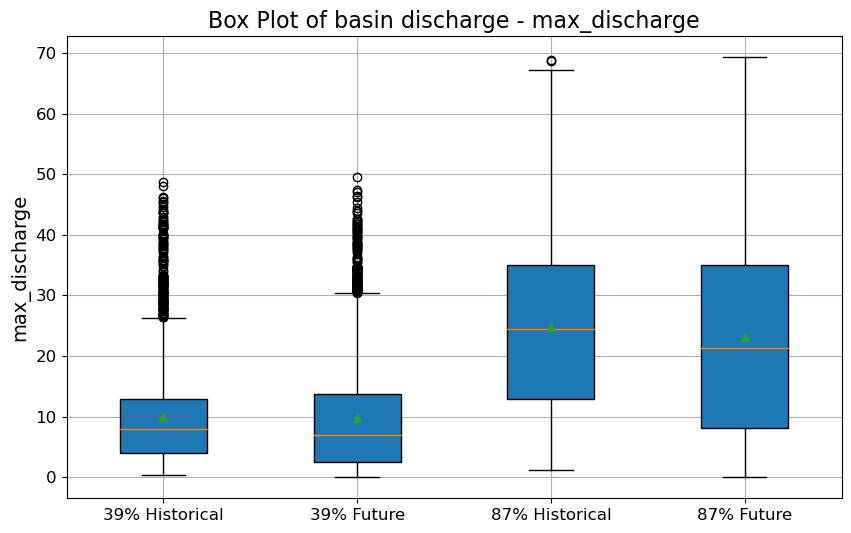

In [14]:
plt.figure(figsize=(10, 6))

# Prepare data for boxplot
data = [
    urbanization_39_historical, urbanization_39_future,
    urbanization_87_historical, urbanization_87_future
]
labels = [
    '39% Historical', '39% Future',
    '87% Historical', '87% Future'
]

# Create boxplot
plt.boxplot(data, labels=labels, patch_artist=True, showmeans=True)

# Add dynamic title and labels
plt.title(f"Box Plot of {dynamic_title}")
plt.ylabel(x_title)
plt.grid(True)

plt.show()


# violinplot

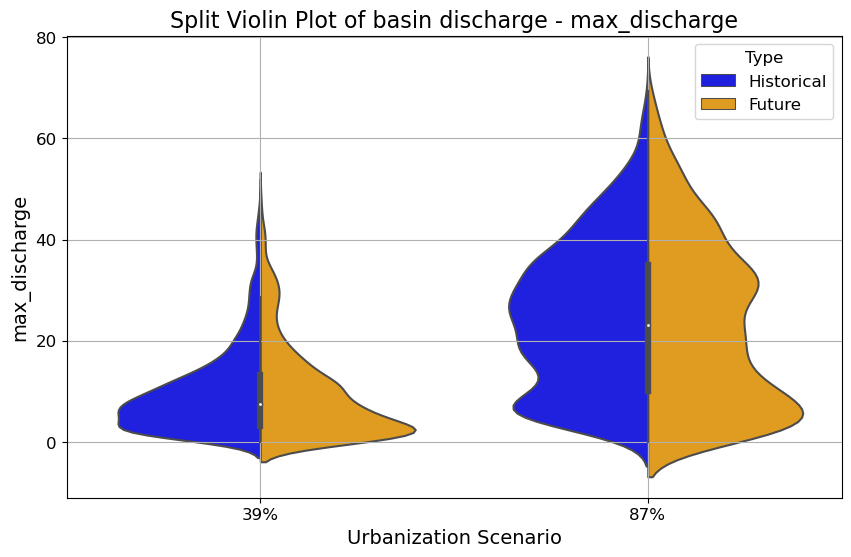

In [15]:
# Combine data for split violin plot
data = {
    x_title: (
        urbanization_39_historical + urbanization_39_future + 
        urbanization_87_historical + urbanization_87_future
    ),
    'Scenario': (
        ['39%'] * len(urbanization_39_historical) +
        ['39%'] * len(urbanization_39_future) +
        ['87%'] * len(urbanization_87_historical) +
        ['87%'] * len(urbanization_87_future)
    ),
    'Type': (
        ['Historical'] * len(urbanization_39_historical) +
        ['Future'] * len(urbanization_39_future) +
        ['Historical'] * len(urbanization_87_historical) +
        ['Future'] * len(urbanization_87_future)
    )
}

df = pd.DataFrame(data)

# Create split violin plot
plt.figure(figsize=(10, 6))
sns.violinplot(
    x='Scenario', 
    y=x_title, 
    hue='Type', 
    data=df, 
    split=True,  # Split the violin by the hue
    palette={'Historical': 'blue', 'Future': 'orange'}
)

# Add dynamic title and labels
plt.title(f"Split Violin Plot of {dynamic_title}")
plt.ylabel(x_title)
plt.xlabel('Urbanization Scenario')
plt.legend(title='Type')
plt.grid(True)

plt.show()
